In [1]:
%matplotlib widget

In [2]:
from dprs import dprs

In [3]:
dprs??

Signature: dprs(x, y)
Source:   
def dprs(x,y):
    """Calls file with implementation"""
    return dprs_compute(x,y)
File:      ~/Development/dprs/src/dprs/main.py
Type:      function

In [4]:
lista = range(10)
dprs(lista,lista)

0.0

In [5]:
from sklearn.metrics import ndcg_score

In [6]:
dpr_worst_7_estimated = 0.5900924472353044 #4.782312925170067

In [15]:
import numpy as np
import random
from itertools import permutations
from tqdm import tqdm  # pip install tqdm


def swap_two_random_elements(lst):
    if len(lst) < 2:
        return lst  # Nothing to swap
    i, j = random.sample(range(len(lst)), 2)  # Get two distinct indices
    lst[i], lst[j] = lst[j], lst[i]           # Swap the elements
    return lst


true_list = list(range(7))

# mutated_list = list(range(10))
perms = permutations(true_list)

from math import factorial
total = factorial(len(true_list))

NDCG_scores = []
DPR_scores = []
print(total)

if True:

    for perm in tqdm(perms, total=total, desc="Permutations"):
        # if n >=0:
        #     n -=1  
        
        # Example: true relevance scores (ground truth)
        # print(perm)
        
        true_relevance = np.asarray([true_list])
    
        # mutated_list = swap_two_random_elements(mutated_list)
    
        # predicted_list = mutated_list
        predicted_scores = np.asarray([perm])
        
        # Compute NDCG score
        score = ndcg_score(true_relevance, predicted_scores) # , k=2
        dpr_score = dprs(true_list, perm)
        # dpr_worst_10 = 49.09090909090914
        dpr_worst_7 = dpr_worst_7_estimated #23.14285714285715
        
        
        # print(f"Raw DPR {dpr_score}")
        
        # print("NDCG score:", score)
        NDCG_scores.append(score)
        # print("DPR score:", 1 - (dpr_score / dpr_worst_10)) # max score is 49.09090909090914 for 10 elements
        dpr_score_n = 1 - (dpr_score / dpr_worst_7)
        DPR_scores.append(dpr_score_n)
        # print("="*50)

print("Finished")

5040


Permutations: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5040/5040 [00:00<00:00, 5953.18it/s]

Finished


In [16]:
def sort_and_sample(input_list , sample_step):
    sorted_ndcg = sorted(list(input_list))
    sampled_ndcg = sorted_ndcg[::sample_step]
    return sampled_ndcg

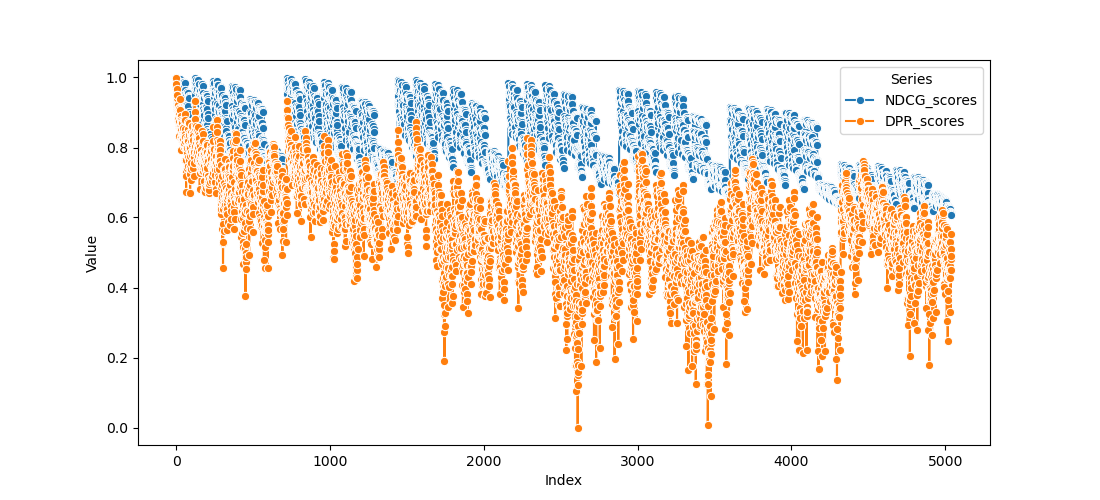

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example data
# series1 = sort_and_sample(NDCG_scores, 1)
# series2 = sort_and_sample(DPR_scores, 1)
series1 = NDCG_scores
series2 = DPR_scores

# Prepare data in long-form for seaborn
data = pd.DataFrame({
    'Index': list(range(len(series1))) * 2,
    'Value': series1 + series2,
    'Series': ['NDCG_scores'] * len(series1) + ['DPR_scores'] * len(series2)
})

# Plot
plt.figure(figsize=(11, 5))
sns.lineplot(data=data, x='Index', y='Value', hue='Series', marker='o')
plt.title('')
plt.show()


## Experiment 2

In [10]:
from math import factorial
import statistics

def stats(my_list):
    if len(my_list) >= 2:
        minimum = min(my_list)
        maximum = max(my_list)
        mean = statistics.mean(my_list)
        std_dev = statistics.stdev(my_list)  # Use pstdev() for population std
        
        print(f"Min: {minimum}")
        print(f"Max: {maximum}")
        print(f"Mean: {mean}")
        print(f"Standard Deviation: {std_dev}")

true_list = list(range(7))

NDCG_scores_2 = []
DPR_scores_2 = []
NDCG_labels = []
DPR_labels = []
same_perms = []

for slice_size in range(1, len(true_list)+1):
    current_perm_slice = true_list[-slice_size:]
    print(current_perm_slice)
    slice_perms = permutations(current_perm_slice)
    fixed_part = true_list[:-slice_size]

    total_slice = factorial(len(current_perm_slice))
    NDCG_scores_2_iter = []
    DPR_scores_2_iter = []
    slice_perms_iter = []

    for slice_perm in tqdm(slice_perms, total=total_slice, desc="Permutations"):
    
        true_relevance = np.asarray([true_list])

        # print(fixed_part)
        # print(slice_perm)
        predicted_list = fixed_part+list(slice_perm)
        predicted_scores = np.asarray([predicted_list])
        
        # Compute NDCG score
        score = ndcg_score(true_relevance, predicted_scores, k=7) # , k=2
        dpr_score = dprs(true_list, predicted_list)
        # dpr_worst_10 = 49.09090909090914
        dpr_worst_7 = dpr_worst_7_estimated #23.14285714285715
        
        # print(f"Raw DPR {dpr_score}")
        
        # print("NDCG score:", score)
        NDCG_scores_2_iter.append(score)
        # print("DPR score:", 1 - (dpr_score / dpr_worst_10)) # max score is 49.09090909090914 for 10 elements
        dpr_score_n = 1 - (dpr_score / dpr_worst_7)
        DPR_scores_2_iter.append(dpr_score_n)
        slice_perms_iter.append(slice_perm)
        

    same_perms.append(slice_perms_iter)
    print(f"For slice_size={slice_perm}")
    stats(NDCG_scores_2_iter)
    stats(DPR_scores_2_iter)
    NDCG_scores_2 += NDCG_scores_2_iter
    DPR_scores_2 += DPR_scores_2_iter
    NDCG_labels += [f"NDCG_{slice_size}" for _ in NDCG_scores_2_iter]
    DPR_labels += [f"DPR_{slice_size}" for _ in DPR_scores_2_iter]


print("Finished")

[6]


Permutations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 471.69it/s]


For slice_size=(6,)
[5, 6]


Permutations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 765.73it/s]


For slice_size=(6, 5)
Min: 0.972815691376063
Max: 1.0
Mean: 0.9864078456880315
Standard Deviation: 0.01922220896985376
Min: 0.9808601832692876
Max: 1.0
Mean: 0.9904300916346438
Standard Deviation: 0.013533894200954482
[4, 5, 6]


...

For slice_size=(6, 5, 4, 3, 2)
Min: 0.7898518773339778
Max: 1.0
Mean: 0.8949259386669889
Standard Deviation: 0.05783094213596201
Min: 0.6695240910434526
Max: 1.0
Mean: 0.8327852497783033
Standard Deviation: 0.0632334065588491
[1, 2, 3, 4, 5, 6]


Permutations: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:00<00:00, 5755.08it/s]


For slice_size=(6, 5, 4, 3, 2, 1)
Min: 0.7038639321724918
Max: 1.0
Mean: 0.8519319660862459
Standard Deviation: 0.07425260371645302
Min: 0.37614543304759096
Max: 1.0
Mean: 0.7200068972312543
Standard Deviation: 0.09440420368904591
[0, 1, 2, 3, 4, 5, 6]


Permutations: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5040/5040 [00:00<00:00, 5802.03it/s]

For slice_size=(6, 5, 4, 3, 2, 1, 0)
Min: 0.6077671813332716
Max: 1.0
Mean: 0.8038835906666357
Standard Deviation: 0.09148104166582091
Min: 0.0
Max: 1.0
Mean: 0.5758941767661839
Standard Deviation: 0.1325248110808446
Finished


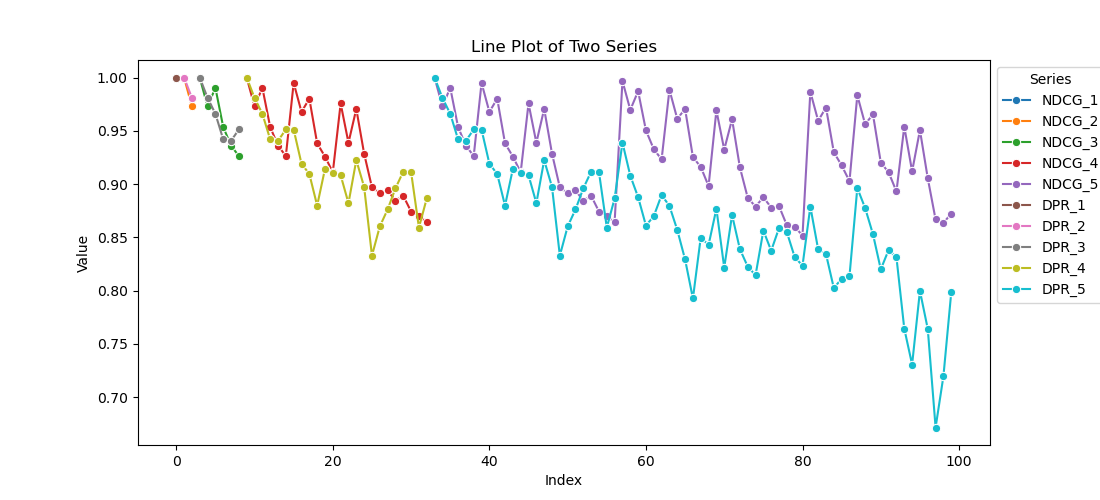

In [11]:
import mplcursors

plt.clf()

zoom_n = 100
series1 = NDCG_scores_2[:zoom_n]
series2 = DPR_scores_2[:zoom_n]
NDCG_labels = NDCG_labels[:zoom_n]
DPR_labels = DPR_labels[:zoom_n]
same_perms_flat = [item for sublist in same_perms for item in sublist][:zoom_n] * 2 

# Prepare data in long-form for seaborn
data = pd.DataFrame({
    'Index': list(range(len(series1))) * 2,
    'Value': series1 + series2,
    'Series': NDCG_labels + DPR_labels
    # 'Series': ['NDCG_scores'] * len(series1) + ['DPR_scores'] * len(series2)
})

# Plot
plt.figure(figsize=(11, 5))
ax = sns.lineplot(data=data, x='Index', y='Value', hue='Series', marker='o')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
cursor2 = mplcursors.cursor(ax.collections[0], hover=True)

@cursor2.connect("add")
def on_add(sel):
    sel.annotation.set_text(same_perms_flat[sel.index])
    
plt.title('Line Plot of Two Series')
plt.show()

# print(series2)
# (5,6,4) -> (6,4,5) -> (6,5,4)  # 5 didn't travel anywhere and information is not lost but the score is the lowest
# 0.9535281174597975, 0.9359875957939935, 0.926343808835860
# (45 - ordc. tr 2+1 | 56 - sord. tr1+1 | 46 - ordc. tr 2+1)   8 tr 2ordc
# (45 - sord. tr 1+1 | 56 - ordc. tr1+2 | 46 - ordc. tr 1+2)   8tr 2 ordch
# (45 - ordc. tr 2+0 | 56 - ordc. tr0+2 | 46 - ordc. tr 2+2)   8 tr 3 ordch

# for 45 : 4 most important and travelled the most, 5 is second most and tr 1

# we also include those pairs outsede of the mutation area
# {04} - got penalty 2 as right edge moved, same for (1,4)(2,4) (3,4) need to incorporate distance change 
# (0,1,2,3,4,5,6) . MAx index difference is 6, n-1. Elements that showed difference in change of distance 4->6 vs 1 to 3 ???
# so the original order is the only source of info. The Further away element were in original ranking the weaker the connection 
# - so the smaller should be a change of this connection
# orig_weakness = [7,6,5,4,3,2,1] # six elements, start from 1 to avoid mult. by 0. With original distance of 1 you get orig_weakness[0] weight

# So the smaller the original distance was in the pair the bigger impact of the shift. 
# Transition from similar to dissimilar is measured by the sum ow weights.
# Inverse order sums intersection point twice and naturally penalized

# (5,6,4) -> (6,4,5) -> (6,5,4)
#0.9074074074074074, 0.9074074074074074, 0.907407407407407

In [61]:
# ramdomly swap pairs and if DPR decreased and NDCG increased...then it is a good sign that new metric is smarter

## Experiment 3

Checking whether there are cases when scoring changes for a single pair mutation disagree in their direction

In [13]:
true_list = list(range(7))

mutated_list = list(range(7))

perms = permutations(true_list)

from math import factorial
total = factorial(len(true_list))

NDCG_scores = []
DPR_scores = []
print(total)
previous_NDCG = 0
previous_DPR = 0
previous_perm = []

if True:

    for perm in tqdm(perms, total=total, desc="Permutations"):

        # Example: true relevance scores (ground truth)
        # print(perm)
        
        true_relevance = np.asarray([true_list])
    
        mutated_list = swap_two_random_elements(mutated_list)
    
        predicted_list = mutated_list
        predicted_scores = np.asarray([predicted_list])
        
        # Compute NDCG score
        score = ndcg_score(true_relevance, predicted_scores) # , k=2
        dpr_score = dprs(true_list, predicted_list)
        # dpr_worst_10 = 49.09090909090914
        dpr_worst_7 = dpr_worst_7_estimated #23.14285714285715
        
        
        # print(f"Raw DPR {dpr_score}")
        
        # print("NDCG score:", score)
        NDCG_scores.append(score)
        # print("DPR score:", 1 - (dpr_score / dpr_worst_10)) # max score is 49.09090909090914 for 10 elements
        dpr_score_n = 1 - (dpr_score / dpr_worst_7)
        DPR_scores.append(dpr_score_n)

        score = round(score, 4)
        dpr_score_n = round(dpr_score_n, 4)
        if previous_NDCG < score and previous_DPR > dpr_score_n :
            print(f"Unusual case 1 (NDCG {previous_NDCG} -> {score} vs {previous_DPR} -> {dpr_score_n}  ): {mutated_list} {previous_perm}")

        if previous_NDCG > score and previous_DPR < dpr_score_n:
            print(f"Unusual case 2 (NDCG {previous_NDCG} -> {score} vs {previous_DPR} -> {dpr_score_n} : {mutated_list} {previous_perm}")

        previous_NDCG = score
        previous_DPR = dpr_score_n
        previous_perm = predicted_list.copy()

        # Unusual case 2 (NDCG 0.8203 -> 0.8097 vs 0.3563 -> 0.3585 : [5, 0, 3, 2, 6, 4, 1] [5, 0, 3, 2, 6, 1, 4]

        # [0, 1, 2, 3, 4, 5, 6] 14 - orig dist is 3
        # [5, 0, 3, 2, 6, 4, 1] 14 - change in dist is 2 ( should we mult. by diff? or travel dist . "1" travels 4, 4 travels 1
        # [5, 0, 3, 2, 6, 1, 4] 14 - "1" travels 3, 4 travels 2
        # relative and absolute changes should be encoded. 
        # 1. Travelling weigts - absolute changes. 
        # 2. weakness weight - orig. relative
        # 2.1 multiply by distance change?  --- not accounted  3 - (-1) = 4 | 3 - 1 = 2   6-(-6) = 12

        # [5, 0, 3, 2, 6, 1, 4] 50 - change in dist is 2 ( should we mult. by diff? or travel dist . "1" travels 4, 4 travels 1
        # [1, 4, 3, 2, 6, 5, 0]  - 50 - orig dist is 1,  index for 0 - index for left five
        # [1, 4, 3, 2, 6, 0, 5]  - 50 - index for 0 minus index for five:  5-6 = -1 
        
        # 3. change of order                --- not accounted  
        # 4. each edge has its own orig. weight that can be used with travel dist ( accounted by travel weights)
print("Finished")

5040


Permutations:   6%|█████████                                                                                                                                               | 302/5040 [00:00<00:01, 3016.41it/s]

Unusual case 1 (NDCG 0.8939 -> 0.9325 vs 0.6678 -> 0.6355  ): [4, 0, 3, 2, 5, 1, 6] [5, 0, 3, 2, 4, 1, 6]
Unusual case 1 (NDCG 0.9325 -> 0.9489 vs 0.6355 -> 0.6264  ): [4, 0, 1, 2, 5, 3, 6] [4, 0, 3, 2, 5, 1, 6]
Unusual case 2 (NDCG 0.719 -> 0.6752 vs 0.4095 -> 0.4599 : [4, 6, 3, 5, 1, 0, 2] [4, 6, 3, 0, 1, 5, 2]
Unusual case 1 (NDCG 0.6752 -> 0.7296 vs 0.4599 -> 0.3028  ): [4, 5, 3, 6, 1, 0, 2] [4, 6, 3, 5, 1, 0, 2]
Unusual case 2 (NDCG 0.7719 -> 0.7176 vs 0.5869 -> 0.6438 : [1, 6, 3, 5, 4, 0, 2] [1, 5, 3, 6, 4, 0, 2]
Unusual case 1 (NDCG 0.7176 -> 0.7595 vs 0.6438 -> 0.6346  ): [1, 3, 6, 5, 4, 0, 2] [1, 6, 3, 5, 4, 0, 2]
Unusual case 1 (NDCG 0.754 -> 0.7707 vs 0.6127 -> 0.6021  ): [3, 1, 6, 5, 2, 0, 4] [3, 1, 6, 5, 4, 0, 2]
Unusual case 2 (NDCG 0.7582 -> 0.7549 vs 0.4104 -> 0.4898 : [2, 3, 6, 5, 1, 4, 0] [2, 3, 6, 5, 0, 4, 1]
Unusual case 1 (NDCG 0.7261 -> 0.7333 vs 0.4606 -> 0.4333  ): [4, 2, 6, 5, 1, 0, 3] [4, 2, 6, 5, 1, 3, 0]
Unusual case 2 (NDCG 0.7333 -> 0.7261 vs 0.4333 -> 0.4

Permutations:  16%|████████████████████████▋                                                                                                                               | 818/5040 [00:00<00:00, 4271.61it/s]

Unusual case 1 (NDCG 0.7639 -> 0.7656 vs 0.6025 -> 0.5116  ): [3, 2, 6, 5, 0, 1, 4] [3, 2, 6, 5, 1, 0, 4]
Unusual case 2 (NDCG 0.8769 -> 0.7931 vs 0.6854 -> 0.6893 : [0, 4, 6, 1, 3, 5, 2] [0, 4, 3, 1, 6, 5, 2]
Unusual case 2 (NDCG 0.8701 -> 0.7228 vs 0.6481 -> 0.6935 : [6, 0, 1, 3, 4, 5, 2] [4, 0, 1, 3, 6, 5, 2]
Unusual case 1 (NDCG 0.7228 -> 0.7325 vs 0.6935 -> 0.6472  ): [6, 0, 1, 2, 4, 5, 3] [6, 0, 1, 3, 4, 5, 2]
Unusual case 2 (NDCG 0.7325 -> 0.7308 vs 0.6472 -> 0.7172 : [6, 1, 0, 2, 4, 5, 3] [6, 0, 1, 2, 4, 5, 3]
Unusual case 1 (NDCG 0.7022 -> 0.7242 vs 0.6036 -> 0.5881  ): [6, 0, 1, 4, 2, 5, 3] [6, 0, 3, 4, 2, 5, 1]
Unusual case 2 (NDCG 0.6935 -> 0.6788 vs 0.582 -> 0.5827 : [6, 0, 5, 3, 2, 1, 4] [6, 0, 3, 5, 2, 1, 4]
Unusual case 1 (NDCG 0.6636 -> 0.6793 vs 0.5404 -> 0.3918  ): [6, 3, 0, 4, 5, 1, 2] [6, 3, 2, 4, 5, 1, 0]


...

Unusual case 2 (NDCG 0.8262 -> 0.7967 vs 0.52 -> 0.5589 : [5, 2, 3, 1, 6, 4, 0] [3, 2, 5, 1, 6, 4, 0]
Unusual case 1 (NDCG 0.6516 -> 0.6622 vs 0.5054 -> 0.4971  ): [5, 6, 2, 3, 1, 4, 0] [5, 6, 2, 3, 4, 1, 0]
Unusual case 1 (NDCG 0.6622 -> 0.6656 vs 0.4971 -> 0.4178  ): [5, 6, 2, 3, 0, 4, 1] [5, 6, 2, 3, 1, 4, 0]
Unusual case 2 (NDCG 0.6656 -> 0.6622 vs 0.4178 -> 0.4971 : [5, 6, 2, 3, 1, 4, 0] [5, 6, 2, 3, 0, 4, 1]
Unusual case 1 (NDCG 0.8095 -> 0.8192 vs 0.5837 -> 0.4895  ): [4, 5, 2, 3, 1, 6, 0] [5, 4, 2, 3, 1, 6, 0]
Unusual case 1 (NDCG 0.8192 -> 0.8247 vs 0.4895 -> 0.4853  ): [4, 5, 2, 1, 3, 6, 0] [4, 5, 2, 3, 1, 6, 0]
Unusual case 2 (NDCG 0.8247 -> 0.6405 vs 0.4853 -> 0.5907 : [6, 5, 2, 1, 3, 4, 0] [4, 5, 2, 1, 3, 6, 0]
Unusual case 1 (NDCG 0.6405 -> 0.6563 vs 0.5907 -> 0.4967  ): [6, 5, 0, 1, 3, 4, 2] [6, 5, 2, 1, 3, 4, 0]
Unusual case 2 (NDCG 0.7514 -> 0.7128 vs 0.4377 -> 0.4584 : [5, 2, 6, 0, 4, 3, 1] [4, 2, 6, 0, 5, 3, 1]
Unusual case 1 (NDCG 0.651 -> 0.6565 vs 0.3563 -> 0.3209

Permutations:  82%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                          | 4157/5040 [00:00<00:00, 5508.48it/s]

Unusual case 2 (NDCG 0.8316 -> 0.8293 vs 0.5442 -> 0.611 : [5, 0, 2, 1, 6, 4, 3] [5, 0, 1, 2, 6, 4, 3]
Unusual case 1 (NDCG 0.8917 -> 0.8949 vs 0.6741 -> 0.6488  ): [5, 2, 3, 1, 0, 4, 6] [5, 3, 2, 1, 0, 4, 6]
Unusual case 1 (NDCG 0.8949 -> 0.9244 vs 0.6488 -> 0.629  ): [3, 2, 5, 1, 0, 4, 6] [5, 2, 3, 1, 0, 4, 6]
Unusual case 1 (NDCG 0.6728 -> 0.857 vs 0.6003 -> 0.5072  ): [4, 2, 5, 1, 0, 6, 3] [6, 2, 5, 1, 0, 4, 3]
Unusual case 1 (NDCG 0.857 -> 0.8688 vs 0.5072 -> 0.4097  ): [4, 0, 5, 1, 2, 6, 3] [4, 2, 5, 1, 0, 6, 3]
Unusual case 2 (NDCG 0.8979 -> 0.8901 vs 0.5681 -> 0.6555 : [1, 4, 2, 5, 0, 6, 3] [1, 4, 0, 5, 2, 6, 3]
Unusual case 1 (NDCG 0.7271 -> 0.7305 vs 0.6324 -> 0.5872  ): [6, 2, 0, 4, 1, 3, 5] [6, 2, 1, 4, 0, 3, 5]
Unusual case 2 (NDCG 0.7521 -> 0.7424 vs 0.6972 -> 0.7134 : [0, 6, 1, 5, 4, 3, 2] [0, 6, 1, 4, 5, 3, 2]
Unusual case 1 (NDCG 0.9024 -> 0.9134 vs 0.7366 -> 0.6292  ): [0, 5, 4, 1, 2, 3, 6] [0, 5, 4, 3, 2, 1, 6]
Unusual case 2 (NDCG 0.7711 -> 0.7167 vs 0.5897 -> 0.603

Permutations: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5040/5040 [00:00<00:00, 5234.93it/s]

Unusual case 2 (NDCG 0.7428 -> 0.6976 vs 0.5973 -> 0.607 : [6, 2, 3, 1, 4, 5, 0] [2, 6, 3, 1, 4, 5, 0]
Unusual case 2 (NDCG 0.9273 -> 0.9256 vs 0.6715 -> 0.685 : [2, 5, 1, 0, 3, 4, 6] [2, 5, 0, 1, 3, 4, 6]
Unusual case 1 (NDCG 0.9622 -> 0.9673 vs 0.7339 -> 0.7166  ): [1, 3, 4, 0, 2, 5, 6] [1, 4, 3, 0, 2, 5, 6]
Unusual case 1 (NDCG 0.7832 -> 0.8647 vs 0.6172 -> 0.5937  ): [1, 3, 5, 4, 2, 6, 0] [1, 3, 6, 4, 2, 5, 0]
Unusual case 2 (NDCG 0.6423 -> 0.6401 vs 0.3548 -> 0.419 : [5, 6, 3, 4, 2, 1, 0] [5, 6, 3, 4, 1, 2, 0]
Unusual case 2 (NDCG 0.6757 -> 0.6718 vs 0.3641 -> 0.3941 : [4, 6, 5, 2, 0, 1, 3] [4, 6, 5, 0, 2, 1, 3]
Unusual case 1 (NDCG 0.6718 -> 0.6763 vs 0.3941 -> 0.3891  ): [4, 6, 5, 1, 0, 2, 3] [4, 6, 5, 2, 0, 1, 3]
Unusual case 2 (NDCG 0.6763 -> 0.6718 vs 0.3891 -> 0.3941 : [4, 6, 5, 2, 0, 1, 3] [4, 6, 5, 1, 0, 2, 3]
Unusual case 1 (NDCG 0.6718 -> 0.6763 vs 0.3941 -> 0.3891  ): [4, 6, 5, 1, 0, 2, 3] [4, 6, 5, 2, 0, 1, 3]
Unusual case 1 (NDCG 0.6966 -> 0.8439 vs 0.4711 -> 0.4485  

In [24]:
import numpy as np

list1 = [15.2,12 ,8, 8, 7,   7,   7,   6,   5, 3]
list2 = [10,  25,  17,  11,  13,  17,  20,  13,  9,   15]
list1 = [4,6]
list2 = [5,7]

corr_matrix = np.corrcoef(list1, list2)
correlation = corr_matrix[0, 1]
print(corr_matrix)
print(correlation) 

[[1. 1.]
 [1. 1.]]
0.9999999999999999


In [30]:
x_line = np.linspace(3, 14, 12)

In [31]:
x_line

array([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.])

In [34]:
np.random.normal(0, 50, 7)

array([ -68.49334829, -104.07951587,  102.21639393,   83.21515832,
        -33.03975834,   29.52735452,  -60.42289709])

In [36]:
np.random.rand(4,3) *10

array([[6.8064201 , 8.4994123 , 8.16304635],
       [3.69205946, 3.48350029, 7.19674325],
       [7.68358757, 1.49535093, 7.51603457],
       [5.67958374, 7.79480356, 3.50016603]])

In [37]:
np.arange(0,20,2)

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [45]:
np.linspace(0,20,29)

array([ 0.        ,  0.71428571,  1.42857143,  2.14285714,  2.85714286,
        3.57142857,  4.28571429,  5.        ,  5.71428571,  6.42857143,
        7.14285714,  7.85714286,  8.57142857,  9.28571429, 10.        ,
       10.71428571, 11.42857143, 12.14285714, 12.85714286, 13.57142857,
       14.28571429, 15.        , 15.71428571, 16.42857143, 17.14285714,
       17.85714286, 18.57142857, 19.28571429, 20.        ])

In [47]:
list(range(1,10, 2))

[1, 3, 5, 7, 9]

In [50]:
np.random.seed(42)  # Set the seed for reproducibility

arr = np.random.random(5)
arr

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864])

In [51]:
rng = np.random.default_rng(seed=45)

In [53]:
ints = rng.integers(0,10, (3,5))

In [55]:
ints

array([[9, 5, 7, 5, 5],
       [7, 7, 8, 5, 5],
       [4, 7, 5, 7, 7]])

In [56]:
x = np.arange(1, 6)
np.add.reduce(x)

15

In [57]:
np.multiply.reduce(x)

120

In [67]:
rng = np.random.default_rng(seed=43)
X = rng.random((10, 2))
X

array([[0.65229926, 0.04377532],
       [0.02002959, 0.83921258],
       [0.58714305, 0.22470523],
       [0.75179227, 0.2636922 ],
       [0.41997791, 0.45103139],
       [0.95531458, 0.89190167],
       [0.27863303, 0.2785343 ],
       [0.42199957, 0.00407772],
       [0.30892377, 0.95175402],
       [0.83820478, 0.53512826]])

In [71]:
el1 = X[:, np.newaxis]
print(el1)

[[[0.65229926 0.04377532]]

 [[0.02002959 0.83921258]]

 [[0.58714305 0.22470523]]

 [[0.75179227 0.2636922 ]]

 [[0.41997791 0.45103139]]

 [[0.95531458 0.89190167]]

 [[0.27863303 0.2785343 ]]

 [[0.42199957 0.00407772]]

 [[0.30892377 0.95175402]]

 [[0.83820478 0.53512826]]]


In [69]:
X[np.newaxis, :].shape
print(X[np.newaxis, :])

[[[0.65229926 0.04377532]
  [0.02002959 0.83921258]
  [0.58714305 0.22470523]
  [0.75179227 0.2636922 ]
  [0.41997791 0.45103139]
  [0.95531458 0.89190167]
  [0.27863303 0.2785343 ]
  [0.42199957 0.00407772]
  [0.30892377 0.95175402]
  [0.83820478 0.53512826]]]


In [72]:
differences = X[:, np.newaxis] - X[np.newaxis, :]
differences

array([[[ 0.        ,  0.        ],
        [ 0.63226968, -0.79543726],
        [ 0.06515622, -0.18092991],
        [-0.09949301, -0.21991687],
        [ 0.23232135, -0.40725606],
        [-0.30301532, -0.84812635],
        [ 0.37366624, -0.23475897],
        [ 0.23029969,  0.0396976 ],
        [ 0.34337549, -0.90797869],
        [-0.18590552, -0.49135293]],

       [[-0.63226968,  0.79543726],
        [ 0.        ,  0.        ],
        [-0.56711346,  0.61450735],
        [-0.73176268,  0.57552039],
        [-0.39994832,  0.3881812 ],
        [-0.93528499, -0.05268909],
        [-0.25860344,  0.56067828],
        [-0.40196999,  0.83513486],
        [-0.28889418, -0.11254143],
        [-0.81817519,  0.30408433]],

       [[-0.06515622,  0.18092991],
        [ 0.56711346, -0.61450735],
        [ 0.        ,  0.        ],
        [-0.16464922, -0.03898697],
        [ 0.16716514, -0.22632616],
        [-0.36817153, -0.66719644],
        [ 0.30851002, -0.05382907],
        [ 0.16514347,  0

In [74]:
dist_sq = differences.sum(-1)
dist_sq

array([[ 0.        , -0.16316758, -0.11577369, -0.31940988, -0.17493471,
        -1.15114166,  0.13890726,  0.26999729, -0.5646032 , -0.67725845],
       [ 0.16316758,  0.        ,  0.04739389, -0.1562423 , -0.01176713,
        -0.98797408,  0.30207485,  0.43316487, -0.40143561, -0.51409087],
       [ 0.11577369, -0.04739389,  0.        , -0.20363619, -0.05916102,
        -1.03536797,  0.25468095,  0.38577098, -0.44882951, -0.56148476],
       [ 0.31940988,  0.1562423 ,  0.20363619,  0.        ,  0.14447517,
        -0.83173178,  0.45831715,  0.58940717, -0.24519331, -0.35784857],
       [ 0.17493471,  0.01176713,  0.05916102, -0.14447517,  0.        ,
        -0.97620695,  0.31384197,  0.444932  , -0.38966849, -0.50232374],
       [ 1.15114166,  0.98797408,  1.03536797,  0.83173178,  0.97620695,
         0.        ,  1.29004893,  1.42113895,  0.58653846,  0.47388321],
       [-0.13890726, -0.30207485, -0.25468095, -0.45831715, -0.31384197,
        -1.29004893,  0.        ,  0.13109002

In [78]:
a = np.array([[1, 2, 3],
              [4, 5, 6]])
print(a.shape)
res = a.sum(-1)    # Output: array([ 6, 15])
print(res)
res.shape

(2, 3)
[ 6 15]


(2,)

In [81]:
pd.Series({2:'a', 1:'b', 3:'c'}, index=[1, 2])

1    b
2    a
dtype: object

In [82]:
A = pd.DataFrame(rng.integers(0, 20, (2, 2)),
columns=['a', 'b'])

In [83]:
A


,a,b
0,9,9
1,16,18


In [88]:
B = pd.DataFrame(rng.integers(0, 10, (3, 3)),
columns=['b', 'a', 'c'])

In [89]:
B

,b,a,c
0,9,5,7
1,9,9,9
2,0,0,5


In [90]:
A + B

,a,b,c
0,14.0,18.0,NaN
1,25.0,27.0,NaN
2,NaN,NaN,NaN


In [91]:
A.add(B, fill_value=42)

,a,b,c
0,14.0,18.0,49.0
1,25.0,27.0,51.0
2,42.0,42.0,47.0


In [92]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris(as_frame=True)
df = iris.frame

# Step 3: Data Cleaning & Preparation
# (Iris dataset is clean, but let's demo missing value handling and encoding.)

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# If missing, we could fill or drop them, e.g.:
# df = df.fillna(df.mean())

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [93]:
from sklearn.model_selection import train_test_split, cross_val_score

In [94]:
import pandas as pd

# Example DataFrame
data = {
    'name': ['Alice', 'Bob', 'Alice', 'David'],
    'age': [25, 30, 25, 40],
    'city': ['NY', 'LA', 'NY', 'Chicago']
}
df = pd.DataFrame(data)

# Find duplicate rows (returns a boolean Series)
duplicates = df.duplicated()

print(duplicates)

0    False
1    False
2     True
3    False
dtype: bool


In [95]:
df.describe()

,age
count,4.000000
mean,30.000000
std,7.071068
min,25.000000
25%,25.000000
50%,27.500000
75%,32.500000
max,40.000000
